In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("loan_prediction.csv")

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [5]:
df.shape

(614, 13)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [7]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [8]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [9]:
df["Gender"].fillna(df["Gender"].mode()[0], inplace=True)
df["Married"].fillna(df["Married"].mode()[0], inplace=True)
df["Dependents"].fillna(df["Dependents"].mode()[0], inplace=True)
df["Self_Employed"].fillna(df["Self_Employed"].mode()[0], inplace=True)
df["LoanAmount"].fillna(df["LoanAmount"].median(), inplace=True)
df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].mode()[0], inplace=True)
df["Credit_History"].fillna(df["Credit_History"].mode()[0], inplace=True)

In [10]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [11]:
df.drop("Loan_ID", axis=1, inplace=True)

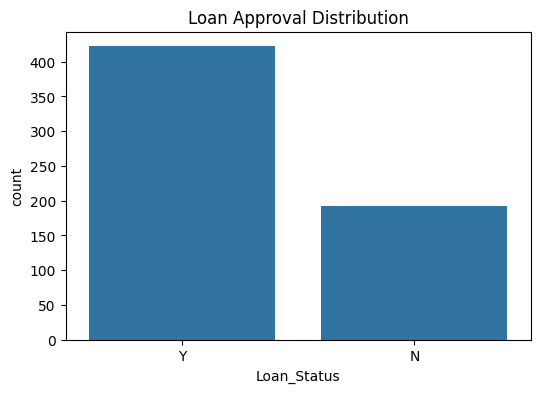

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x="Loan_Status", data=df)
plt.title("Loan Approval Distribution")
plt.show()

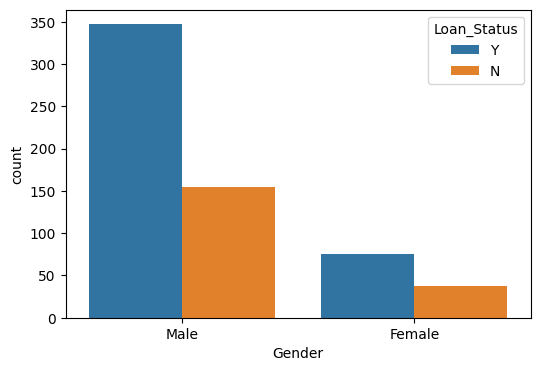

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x="Gender", hue="Loan_Status", data=df)
plt.show()

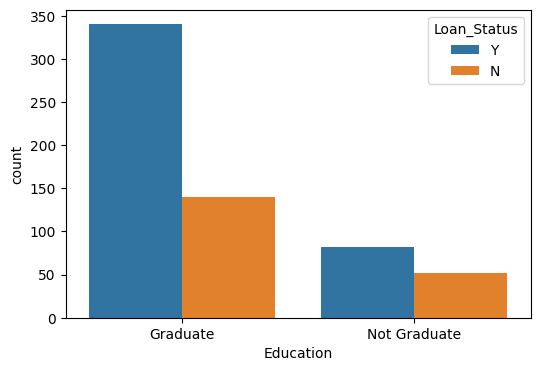

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x="Education", hue="Loan_Status", data=df)
plt.show()

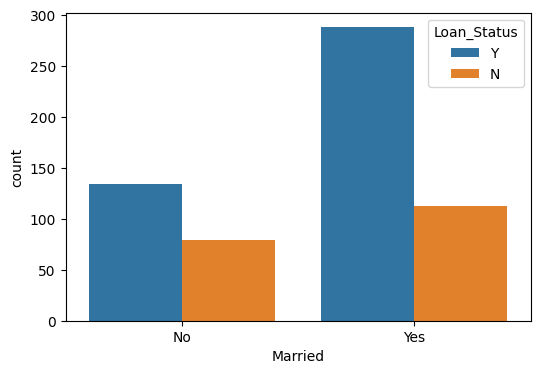

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x="Married", hue="Loan_Status", data=df)
plt.show()

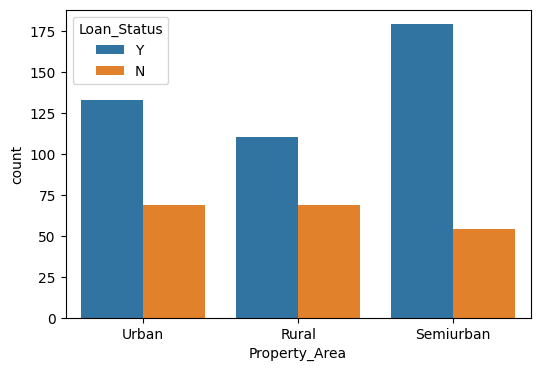

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x="Property_Area", hue="Loan_Status", data=df)
plt.show()

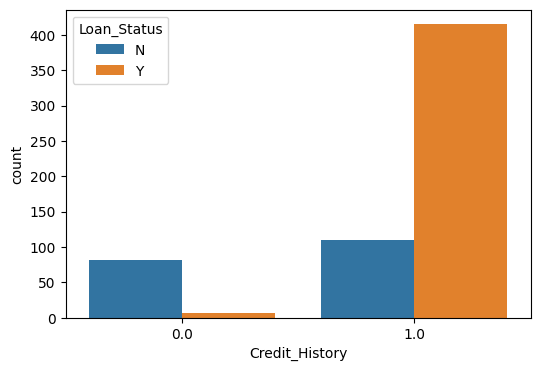

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(x="Credit_History", hue="Loan_Status", data=df)
plt.show()

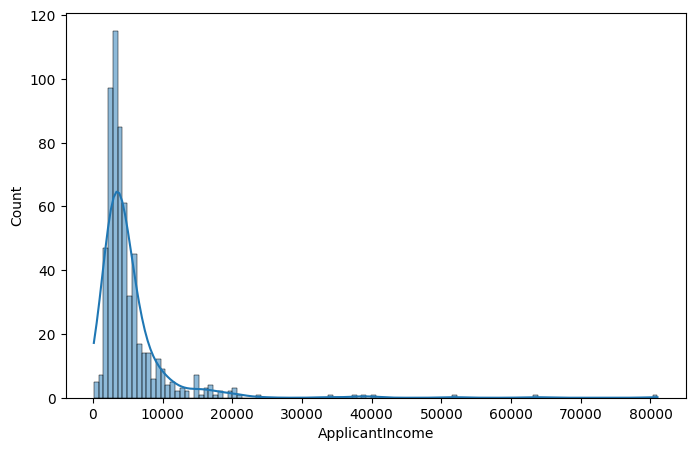

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df["ApplicantIncome"], kde=True)
plt.show()

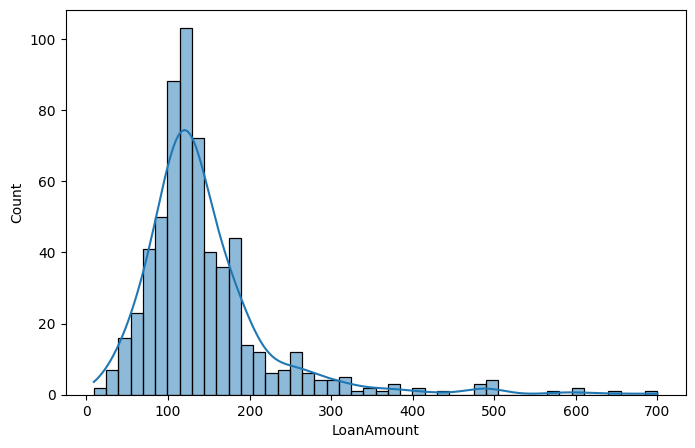

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df["LoanAmount"], kde=True)
plt.show()

In [20]:
encoder = LabelEncoder()

cols = df.select_dtypes(include="object").columns

for col in cols:
    df[col] = encoder.fit_transform(df[col])

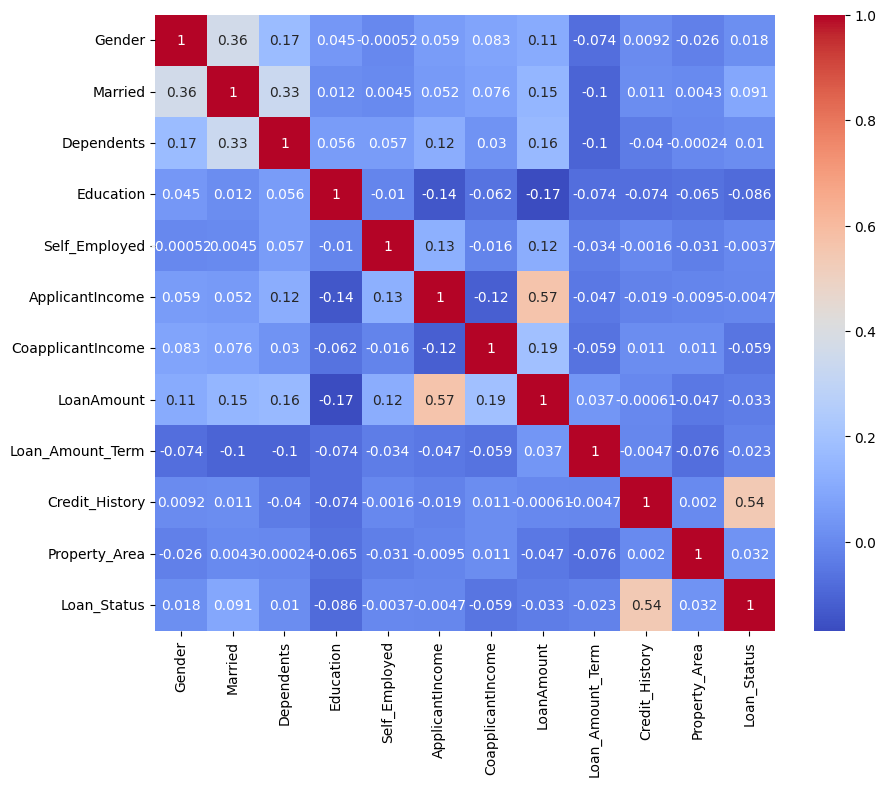

In [21]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [22]:
X = df.drop("Loan_Status", axis=1)

y = df["Loan_Status"]

In [23]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [26]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [27]:
svm = SVC()

svm.fit(X_train, y_train)

pred_svm = svm.predict(X_test)

In [28]:
def evaluate(y_true, y_pred):

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision :", precision_score(y_true, y_pred))
    print("Recall :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    print()

    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print(classification_report(y_true, y_pred))

Accuracy : 0.7886178861788617
Precision : 0.7596153846153846
Recall : 0.9875
F1 Score : 0.8586956521739131



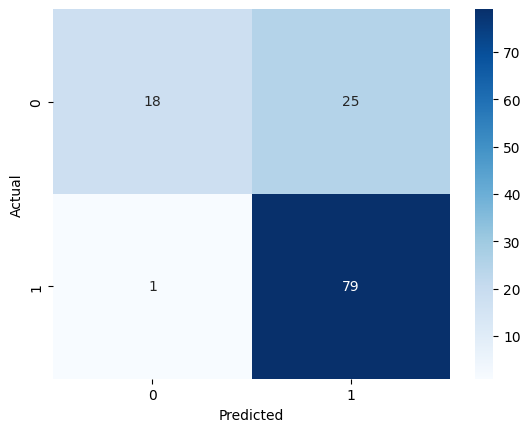

              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



In [29]:
evaluate(y_test, pred_lr)

Accuracy : 0.7560975609756098
Precision : 0.75
Recall : 0.9375
F1 Score : 0.8333333333333334



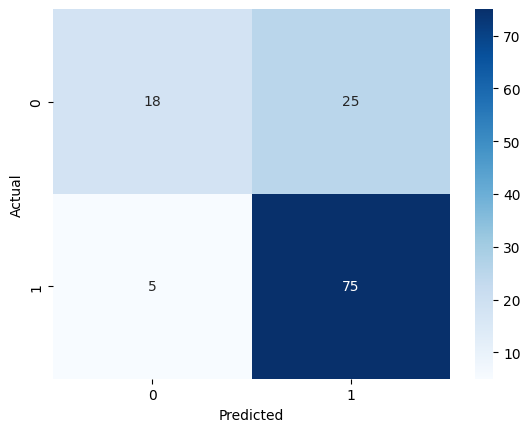

              precision    recall  f1-score   support

           0       0.78      0.42      0.55        43
           1       0.75      0.94      0.83        80

    accuracy                           0.76       123
   macro avg       0.77      0.68      0.69       123
weighted avg       0.76      0.76      0.73       123



In [30]:
evaluate(y_test, pred_rf)

Accuracy : 0.7886178861788617
Precision : 0.7596153846153846
Recall : 0.9875
F1 Score : 0.8586956521739131



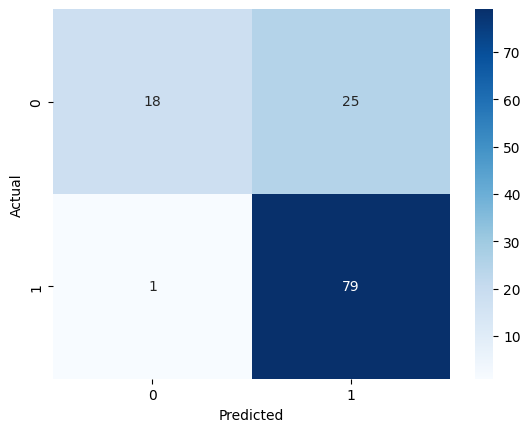

              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



In [31]:
evaluate(y_test, pred_svm)

In [32]:
models = {
    "Logistic Regression": pred_lr,
    "Random Forest": pred_rf,
    "SVM": pred_svm
}

results = []

for name, pred in models.items():

    results.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred)
    ])

comparison = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.788618,0.759615,0.9875,0.858696
1,Random Forest,0.756098,0.750000,0.9375,0.833333
2,SVM,0.788618,0.759615,0.9875,0.858696


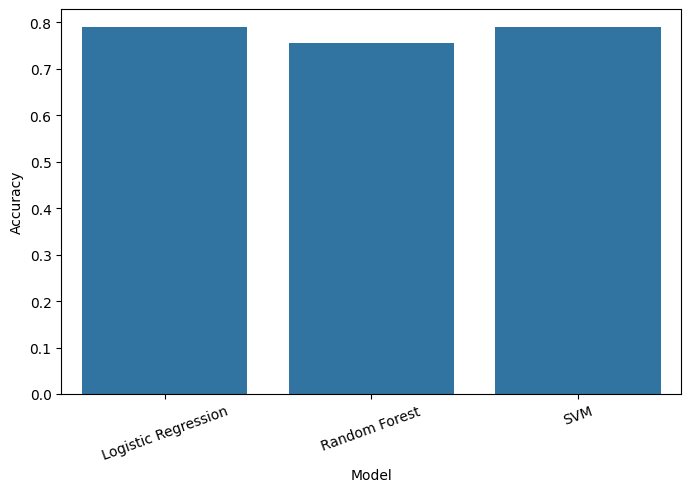

In [33]:
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="Accuracy", data=comparison)
plt.xticks(rotation=20)
plt.show()

In [34]:
# logistic regression gives best result
# so saving that model
import joblib

joblib.dump(lr, "loan_prediction_model.pkl")

['loan_prediction_model.pkl']